# 037 约束与非光滑优化
先重新启动内核，从第一格顺序运行。此Notebook绑定默认数据、配置和数值/绘图代码；合法但不同的数据也会被首格拒绝。自定义实验请使用CLI。所有图片由本次代码重新计算。

In [1]:
from pathlib import Path
import hashlib, json, os, sys
ROOT = Path.cwd().resolve()
EXPECTED = {'data/regression.csv': 'ceb8b9714329621915b48941973270e4621b8c36a1e8a09ab44e6192a610155d', 'data/model_spec.json': '31f8f77a12923784553156be71fc52402981c6725b2cf25ea609635d0926860d', 'experiment.py': '41f9139f51af672551ef59b8ff9e760bfd60e58978fbd9aa5fae45b26457826f', 'build_assets.py': '7b10a09d0c92a5d41f70d9d7be6e8747434da1965550070111d09ee568756f04'}
for relative, expected in EXPECTED.items():
    path = ROOT / relative
    if not path.is_file() or hashlib.sha256(path.read_bytes()).hexdigest() != expected:
        raise ValueError("Default input SHA mismatch: " + relative)
# No numeric library import, solver, numeric output or figure occurs before all checks.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/unit037-notebook-mpl")
sys.path.insert(0, str(ROOT))
print("All default input SHA checks passed.")

All default input SHA checks passed.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image
from io import BytesIO
from experiment import load_inputs, run_experiment, write_report
from build_assets import make_figure
print("NumPy", np.__version__)
data, spec = load_inputs()
report = run_experiment(data, spec)
print("Data =", data.tolist())
print("Config =", spec)
print("Statuses =", {k: (v['status'], v['completed_updates']) for k,v in report['paths'].items()})

NumPy 2.3.5
Data = [[-1.0, -1.0, -1.75], [-1.0, 1.0, -2.25], [1.0, -1.0, 1.25], [1.0, 1.0, 2.75]]
Config = {'kind': 'synthetic_lasso_two_features', 'initial_parameters': [0.0, 0.5], 'steps': 80, 'learning_rate': 0.5, 'lambda': 0.5, 'tolerance': 1e-10, 'lower_bounds': [0.0, 0.0], 'upper_bounds': [1.0, 1.0], 'coordinate_order': [0, 1], 'stress_rho': 0.875}
Statuses = {'proximal': ('tolerance_satisfied', 34), 'subgradient': ('fixed_budget_completed', 80), 'projected': ('tolerance_satisfied', 32), 'coordinate': ('tolerance_satisfied', 1)}


## 从原始四行重建两轮
每轮保留全部旧预测、残差、半平方、局部导数、平均梯度分项、试探点及新前向。Fraction结果与实际浮点结果分开。

In [3]:
for t, tr in enumerate(report['paths']['proximal']['trace'][:2], 1):
    print("UPDATE", t)
    print(json.dumps(tr, ensure_ascii=False, indent=2))
print("EXACT FRACTION LEDGER")
print(json.dumps(report['exact_first_two'], ensure_ascii=False, indent=2))

UPDATE 1
{
  "old_forward": {
    "theta": [
      0.0,
      0.5
    ],
    "rows": [
      {
        "id": 1,
        "x": [
          -1.0,
          -1.0
        ],
        "y": -1.75,
        "parameter_products": [
          -0.0,
          -0.5
        ],
        "prediction": -0.5,
        "residual": 1.25,
        "half_square": 0.78125,
        "d_loss_d_residual": 1.25,
        "d_residual_d_prediction": 1.0,
        "d_prediction_d_theta": [
          -1.0,
          -1.0
        ],
        "mean_gradient_contribution": [
          -0.3125,
          -0.3125
        ]
      },
      {
        "id": 2,
        "x": [
          -1.0,
          1.0
        ],
        "y": -2.25,
        "parameter_products": [
          -0.0,
          0.5
        ],
        "prediction": 0.5,
        "residual": 2.75,
        "half_square": 3.78125,
        "d_loss_d_residual": 2.75,
        "d_residual_d_prediction": 1.0,
        "d_prediction_d_theta": [
          -1.0,
          1.0
      

## 绝对值尖点与整个次梯度区间
此图重新调用已验证数据的计算函数，没有读取预生成PNG。

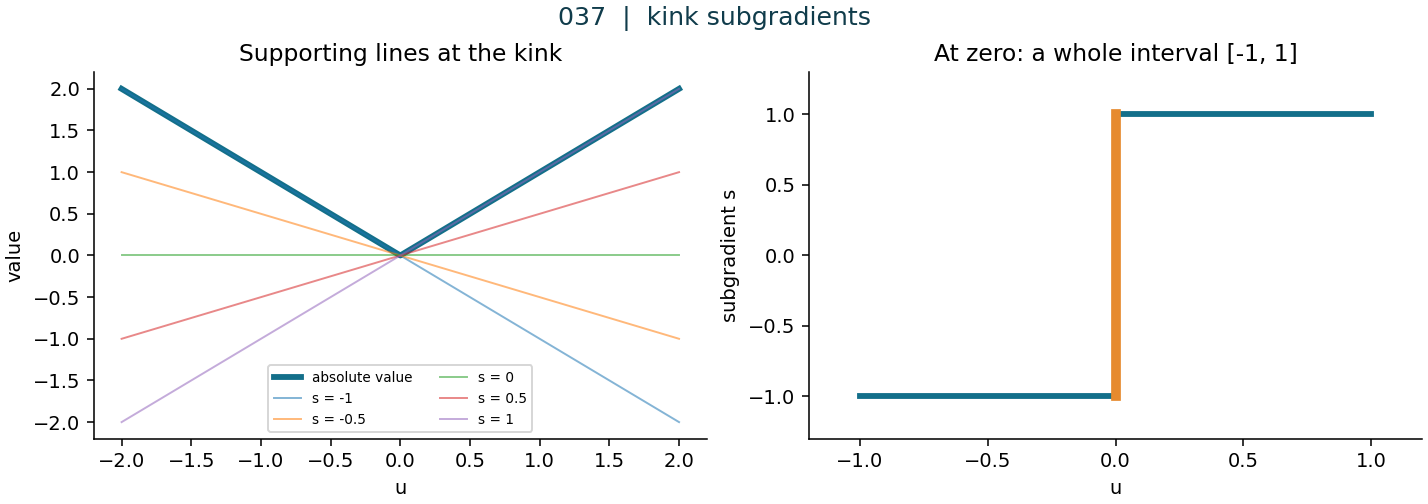

In [4]:
fig = make_figure(1, data, spec)
buffer = BytesIO()
fig.savefig(buffer, format="png")
display(Image(data=buffer.getvalue()))
plt.close(fig)

## 近端标量问题与阈值闭区间
此图重新调用已验证数据的计算函数，没有读取预生成PNG。

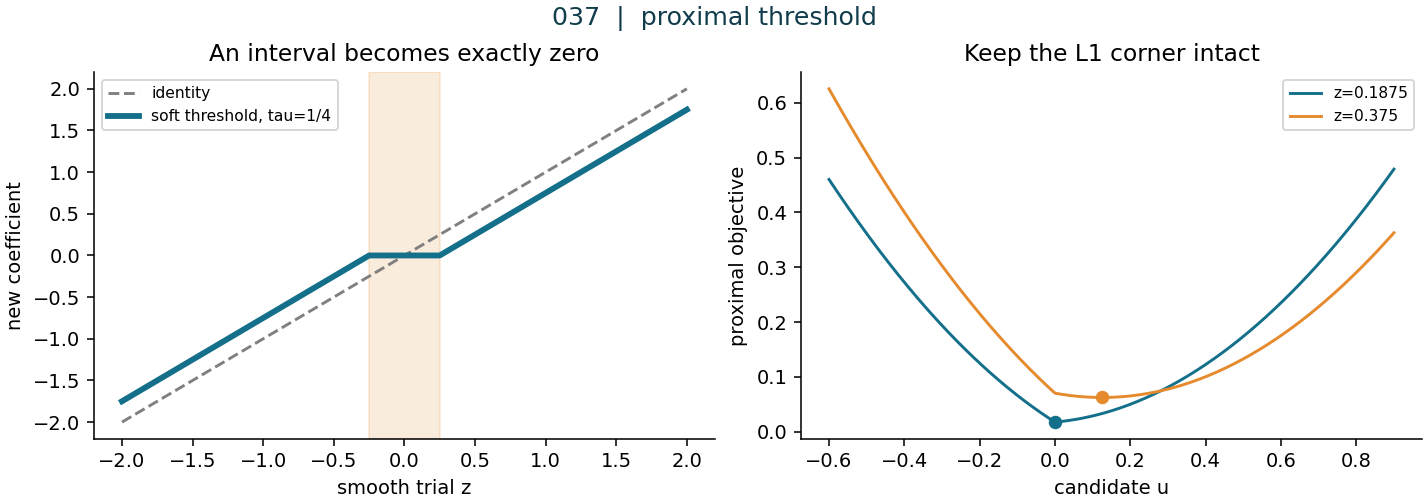

In [5]:
fig = make_figure(2, data, spec)
buffer = BytesIO()
fig.savefig(buffer, format="png")
display(Image(data=buffer.getvalue()))
plt.close(fig)

## 两轮逐样本计算账本
此图重新调用已验证数据的计算函数，没有读取预生成PNG。

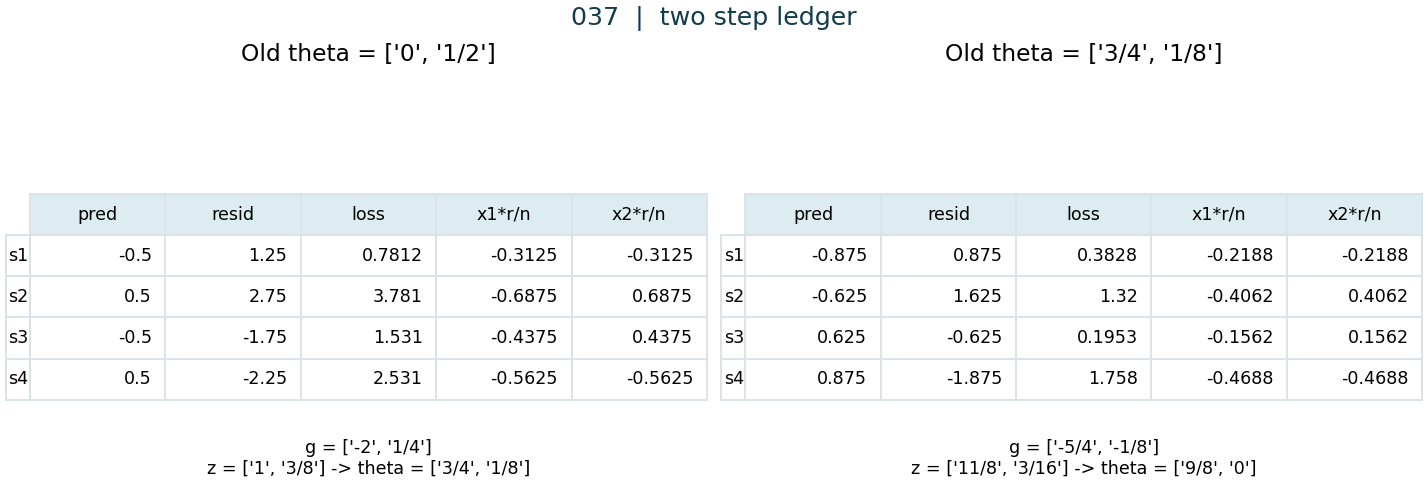

In [6]:
fig = make_figure(3, data, spec)
buffer = BytesIO()
fig.savefig(buffer, format="png")
display(Image(data=buffer.getvalue()))
plt.close(fig)

## 相同主目标与严格零系数计数
此图重新调用已验证数据的计算函数，没有读取预生成PNG。

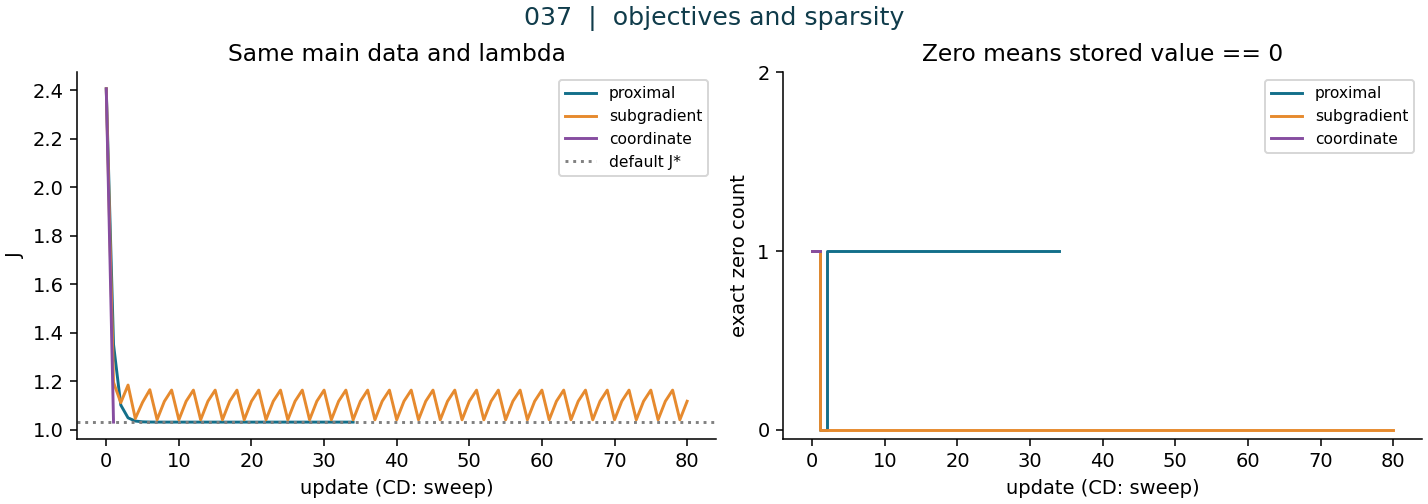

In [7]:
fig = make_figure(4, data, spec)
buffer = BytesIO()
fig.savefig(buffer, format="png")
display(Image(data=buffer.getvalue()))
plt.close(fig)

## 三类残差与默认已知目标差
此图重新调用已验证数据的计算函数，没有读取预生成PNG。

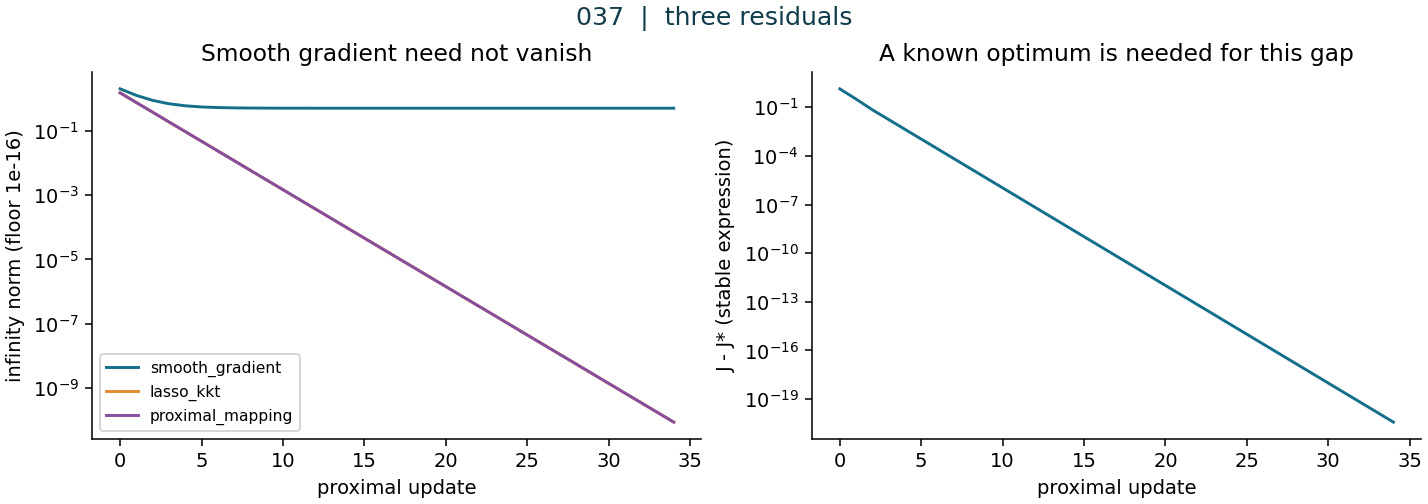

In [8]:
fig = make_figure(5, data, spec)
buffer = BytesIO()
fig.savefig(buffer, format="png")
display(Image(data=buffer.getvalue()))
plt.close(fig)

## 单独光滑盒约束问题
此图重新调用已验证数据的计算函数，没有读取预生成PNG。

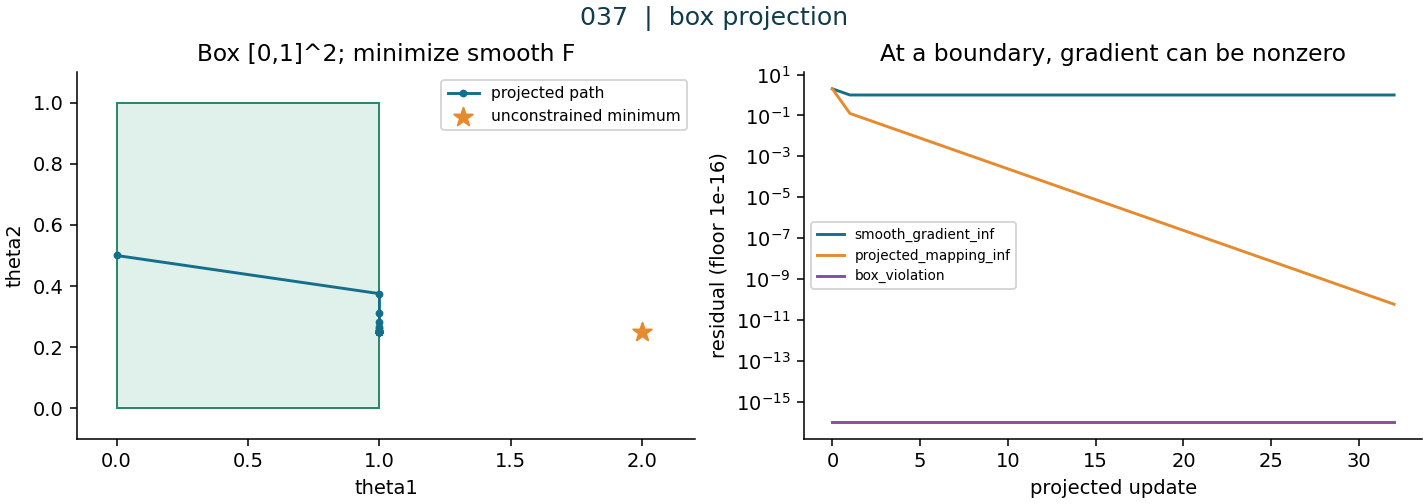

In [9]:
fig = make_figure(6, data, spec)
buffer = BytesIO()
fig.savefig(buffer, format="png")
display(Image(data=buffer.getvalue()))
plt.close(fig)

## 显式相关设计中的顺序坐标法
此图重新调用已验证数据的计算函数，没有读取预生成PNG。

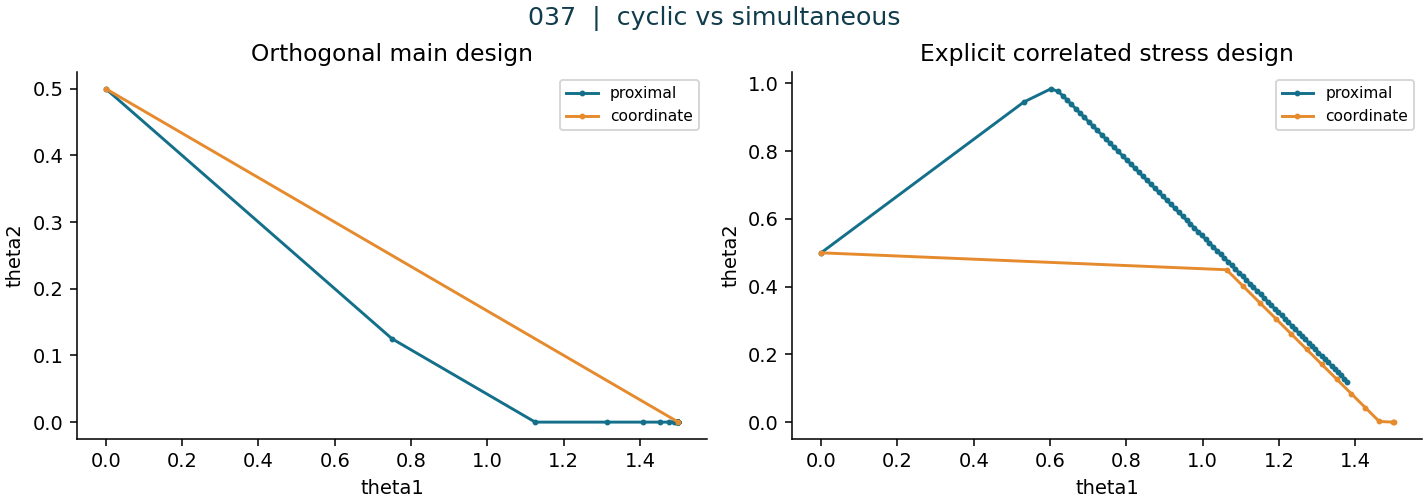

In [10]:
fig = make_figure(7, data, spec)
buffer = BytesIO()
fig.savefig(buffer, format="png")
display(Image(data=buffer.getvalue()))
plt.close(fig)

## 固定步长次梯度失败机制
此图重新调用已验证数据的计算函数，没有读取预生成PNG。

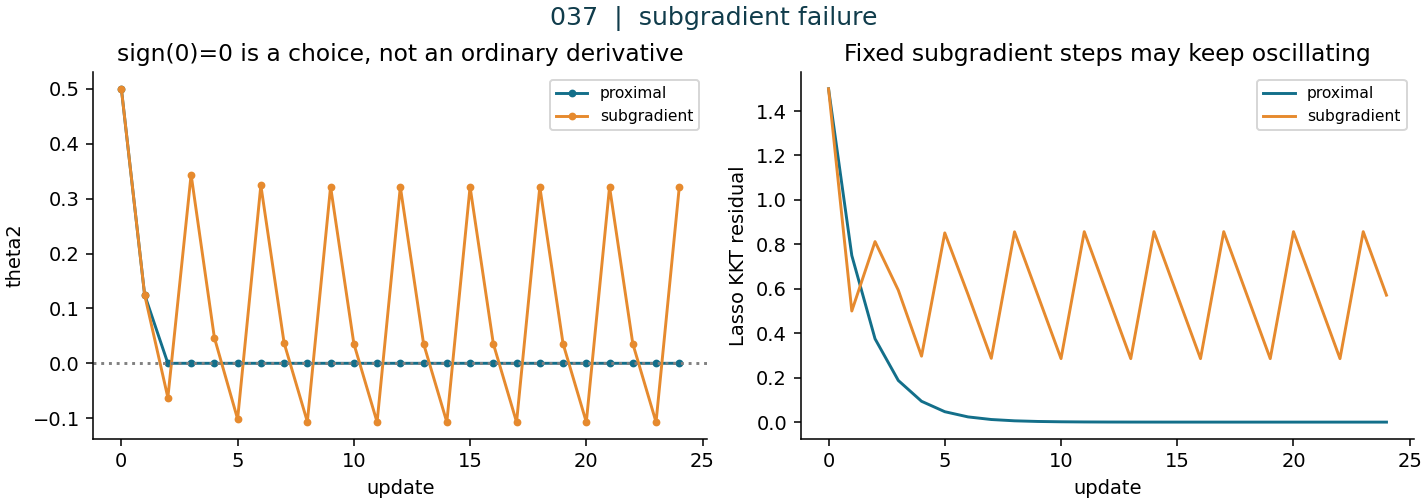

In [11]:
fig = make_figure(8, data, spec)
buffer = BytesIO()
fig.savefig(buffer, format="png")
display(Image(data=buffer.getvalue()))
plt.close(fig)

## 保存完整运行报告
输出保护会拒绝教材资产、输入、symlink/hardlink目标。不能把预算耗尽写成收敛。

In [12]:
saved = write_report(report, ROOT / "notebook_results" / "report.json")
print(json.dumps(saved, indent=2))
for method, path in report['paths'].items():
    print(method, path['final_theta'], path['final_diagnostics']['stopping_residual'], path['status'])

{
  "bytes": 2127554,
  "sha256": "8d183926d7ac08f42ac5ee36d2e445da22ff97eae75e517b861249d40bfe6efe"
}
proximal [1.4999999999126885, 0.0] 8.731149137020111e-11 tolerance_satisfied
subgradient [1.5, -0.1071428571428571] 0.8571428571428572 fixed_budget_completed
projected [1.0, 0.25000000005820766] 5.820766091346741e-11 tolerance_satisfied
coordinate [1.5, 0.0] 0.0 tolerance_satisfied
